# 03 — ONS EDA: UK Calibration Baseline

**Phase 1, Week 2 — independent EDA of three ONS/HMRC datasets to provide UK calibration figures for the project.**

**Goal:** Extract headline UK numbers on (i) sickness absence rates and trends, (ii) earnings levels, (iii) employee flows. These feed into ROI calculations and provide the UK structural backdrop for the EWCS-based wellbeing analysis.

**Datasets:**
- `sicknessabsence2025.xlsx` — ONS Sickness Absence in the UK Labour Market, 1995–2025
- `selectedestimates19972025.xlsx` — ASHE Selected Estimates, UK earnings 1997–2025
- `rtinsamay2026.xlsx` — HMRC PAYE Real Time Information, May 2026 release (employment + pay + flows)

**Approach:** Light EDA. These are pre-aggregated official statistics — we extract numbers and plot trends, not run statistical inference.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)

PROJECT_ROOT = Path.cwd().parent
ONS_DIR = PROJECT_ROOT / "data" / "external" / "ons"
OUTPUTS_FIGURES = PROJECT_ROOT / "outputs" / "figures"
OUTPUTS_TABLES = PROJECT_ROOT / "outputs" / "tables"

# File paths
SICKNESS_PATH = ONS_DIR / "sicknessabsence2025.xlsx"
ASHE_PATH = ONS_DIR / "selectedestimates19972025.xlsx"
RTI_PATH = ONS_DIR / "rtinsamay2026.xlsx"

# Confirm all three files exist
for path in [SICKNESS_PATH, ASHE_PATH, RTI_PATH]:
    print(f"{path.name}: {'✓' if path.exists() else '✗ MISSING'}")

print(f"\nProject root: {PROJECT_ROOT}")

sicknessabsence2025.xlsx: ✓
selectedestimates19972025.xlsx: ✓
rtinsamay2026.xlsx: ✓

Project root: /Users/abhisheksharma/Documents/WellmatchRepo/Wellmatch-Ltd


---

## Part 1: Sickness Absence

UK sickness absence rates 1995–2025, broken down by reason, sector, long-term-health status, and industry.
The release is from June 2025, with 2025 estimates added by ONS on 1 May 2026.

**Tables we extract from:**
- Table 1: UK overall absence rate by year (headline number)
- Table 3: Days lost per worker by year
- Table 4a: % of days lost by reason (mental health share)
- Table 10: Absence rate by long-term-health-condition status
- Table 21: Absence rate by industry sector (2019–2025)

In [3]:
# Load Table 1 — UK sickness absence rate, 1995-2025
# ONS files have a title row + notes + then the data
# First load with no header to see the structure
raw = pd.read_excel(SICKNESS_PATH, sheet_name='Table 1', header=None)
print("Shape:", raw.shape)
print("\nFirst 10 rows:")
print(raw.head(10))

Shape: (35, 2)

First 10 rows:
                                                   0                           1
0  Worksheet 1: Sickness absence rate [note 1,2],...                         NaN
1  This worksheet contains one table. Some cells ...                         NaN
2  Source: Labour Force Survey person datasets [n...                         NaN
3                                               Year  Sickness absence rate\n(%)
4                                               1995                         3.1
5                                               1996                         2.9
6                                               1997                           3
7                                               1998                         2.9
8                                               1999                           3
9                                               2000                         2.9


In [4]:
# Load Table 1 properly: data starts at row 3 (header), data values from row 4
absence_uk = pd.read_excel(SICKNESS_PATH, sheet_name='Table 1', skiprows=3)
absence_uk.columns = ['year', 'absence_rate_pct']

# Drop any rows where year isn't a valid number (footnotes at bottom)
absence_uk = absence_uk[pd.to_numeric(absence_uk['year'], errors='coerce').notna()].copy()
absence_uk['year'] = absence_uk['year'].astype(int)
absence_uk['absence_rate_pct'] = pd.to_numeric(absence_uk['absence_rate_pct'])

print(f"Years covered: {absence_uk['year'].min()} – {absence_uk['year'].max()}")
print(f"Records: {len(absence_uk)}")
print(f"\nFirst 5 years:")
print(absence_uk.head())
print(f"\nLast 5 years:")
print(absence_uk.tail())

# Quick headline numbers
latest = absence_uk.iloc[-1]
print(f"\nLatest year ({latest['year']}): UK absence rate = {latest['absence_rate_pct']}%")
print(f"30-year average: {absence_uk['absence_rate_pct'].mean():.2f}%")
print(f"Lowest year: {absence_uk.loc[absence_uk['absence_rate_pct'].idxmin(), 'year']} at {absence_uk['absence_rate_pct'].min()}%")
print(f"Highest year: {absence_uk.loc[absence_uk['absence_rate_pct'].idxmax(), 'year']} at {absence_uk['absence_rate_pct'].max()}%")

Years covered: 1995 – 2025
Records: 28

First 5 years:
   year  absence_rate_pct
0  1995               3.1
1  1996               2.9
2  1997               3.0
3  1998               2.9
4  1999               3.0

Last 5 years:
    year  absence_rate_pct
23  2018               2.0
27  2022               2.6
28  2023               2.3
29  2024               2.0
30  2025               2.0

Latest year (2025.0): UK absence rate = 2.0%
30-year average: 2.44%
Lowest year: 2017 at 1.9%
Highest year: 1995 at 3.1%


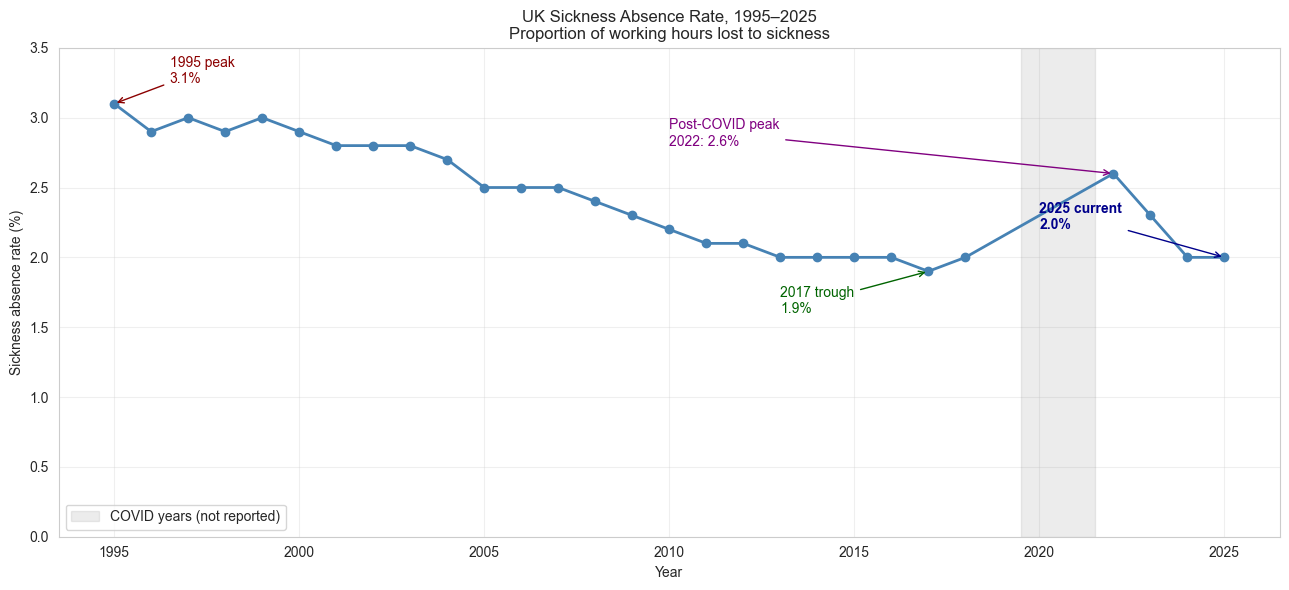

Saved: outputs/figures/ons_absence_rate_uk.png


In [5]:
# Plot UK absence rate over time
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(absence_uk['year'], absence_uk['absence_rate_pct'], 
        marker='o', linewidth=2, color='steelblue', markersize=6)

# Highlight the COVID gap
ax.axvspan(2019.5, 2021.5, alpha=0.15, color='gray', label='COVID years (not reported)')

# Annotate key points
latest = absence_uk.iloc[-1]
peak = absence_uk.loc[absence_uk['absence_rate_pct'].idxmax()]
trough = absence_uk.loc[absence_uk['absence_rate_pct'].idxmin()]

ax.annotate(f'1995 peak\n{peak["absence_rate_pct"]}%', 
            xy=(peak['year'], peak['absence_rate_pct']),
            xytext=(peak['year'] + 1.5, peak['absence_rate_pct'] + 0.15),
            fontsize=10, color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred'))

ax.annotate(f'2017 trough\n{trough["absence_rate_pct"]}%', 
            xy=(trough['year'], trough['absence_rate_pct']),
            xytext=(trough['year'] - 4, trough['absence_rate_pct'] - 0.3),
            fontsize=10, color='darkgreen',
            arrowprops=dict(arrowstyle='->', color='darkgreen'))

ax.annotate(f'2025 current\n{latest["absence_rate_pct"]}%', 
            xy=(latest['year'], latest['absence_rate_pct']),
            xytext=(latest['year'] - 5, latest['absence_rate_pct'] + 0.2),
            fontsize=10, color='darkblue', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='darkblue'))

# 2022 post-COVID peak
peak_post = absence_uk[absence_uk['year'] == 2022].iloc[0]
ax.annotate(f'Post-COVID peak\n2022: {peak_post["absence_rate_pct"]}%', 
            xy=(2022, peak_post['absence_rate_pct']),
            xytext=(2010, peak_post['absence_rate_pct'] + 0.2),
            fontsize=10, color='purple',
            arrowprops=dict(arrowstyle='->', color='purple'))

ax.set_xlabel('Year')
ax.set_ylabel('Sickness absence rate (%)')
ax.set_title('UK Sickness Absence Rate, 1995–2025\nProportion of working hours lost to sickness')
ax.legend(loc='lower left')
ax.set_ylim(0, 3.5)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / 'ons_absence_rate_uk.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: outputs/figures/ons_absence_rate_uk.png")

In [6]:
# Load Table 3 — Days lost per worker by year
days_per_worker = pd.read_excel(SICKNESS_PATH, sheet_name='Table 3', skiprows=3)
days_per_worker.columns = ['year', 'days_per_worker']

# Clean
days_per_worker = days_per_worker[
    pd.to_numeric(days_per_worker['year'], errors='coerce').notna()
].copy()
days_per_worker['year'] = days_per_worker['year'].astype(int)
days_per_worker['days_per_worker'] = pd.to_numeric(days_per_worker['days_per_worker'])

print(f"Records: {len(days_per_worker)}")
print(f"\nFirst 3 years:")
print(days_per_worker.head(3))
print(f"\nLast 5 years:")
print(days_per_worker.tail(5))

latest = days_per_worker.iloc[-1]
print(f"\n>>> KEY CALIBRATION NUMBER <<<")
print(f"Latest year ({latest['year']}): UK average days lost per worker = {latest['days_per_worker']}")

Records: 28

First 3 years:
   year  days_per_worker
0  1995              7.2
1  1996              6.8
2  1997              6.9

Last 5 years:
    year  days_per_worker
23  2018              4.4
27  2022              5.7
28  2023              4.9
29  2024              4.4
30  2025              4.4

>>> KEY CALIBRATION NUMBER <<<
Latest year (2025.0): UK average days lost per worker = 4.4


In [7]:
# Load Table 4a — % of days lost by reason, 2009-2025
# This table is wide (one column per year), so let's inspect first
raw_4a = pd.read_excel(SICKNESS_PATH, sheet_name='Table 4a', header=None)
print(f"Shape: {raw_4a.shape}")
print(f"\nFirst 8 rows × first 6 cols:")
print(raw_4a.iloc[:8, :6])

Shape: (17, 18)

First 8 rows × first 6 cols:
                                                   0                       1                       2                       3                          4                                   5
0  Worksheet 4a: Percentage of days lost through ...                     NaN                     NaN                     NaN                        NaN                                 NaN
1  This worksheet contains one table. Some cells ...                     NaN                     NaN                     NaN                        NaN                                 NaN
2  Source: Labour Force Survey person datasets [n...                     NaN                     NaN                     NaN                        NaN                                 NaN
3                          Reason given for sickness  2025\n(%age days lost)  2024\n(%age days lost)  2023\n(%age days lost)  2022\n(%age of days lost)  2021 [note 5]\n(%age of days lost)
4             

In [8]:
# Load Table 4a — % of days lost by reason, 2009-2025
# Table is wide (years as columns); we'll reshape to long format

raw_4a = pd.read_excel(SICKNESS_PATH, sheet_name='Table 4a', skiprows=3)

# First column is the reason; rest are years
# Clean up column names — extract just the year number from labels like "2025\n(%age days lost)"
new_cols = ['reason']
for col in raw_4a.columns[1:]:
    # Extract first 4 digits if present
    col_str = str(col).strip()
    year_match = ''.join([c for c in col_str[:4] if c.isdigit()])
    new_cols.append(int(year_match) if year_match else col_str)

raw_4a.columns = new_cols

# Drop rows where reason is NaN or where it's a footnote line
absence_by_reason = raw_4a[raw_4a['reason'].notna()].copy()

# Clean reason text — strip the [note X] suffix
absence_by_reason['reason'] = absence_by_reason['reason'].astype(str).str.replace(
    r'\s*\[note[^\]]*\]', '', regex=True
).str.strip()

# Drop any "Total" row if present
absence_by_reason = absence_by_reason[~absence_by_reason['reason'].str.lower().str.contains('total', na=False)]

print("Reasons captured:")
print(absence_by_reason['reason'].tolist())
print(f"\nYears captured: {[c for c in absence_by_reason.columns if isinstance(c, int)]}")
print(f"\nFull table:")
print(absence_by_reason.to_string(index=False))

Reasons captured:
['Minor illnesses', 'Musculoskeletal problems', 'Other', 'Mental health conditions', 'Gastrointestinal problems', 'Respiratory conditions', 'Eye/ear/nose/mouth/dental problems', 'Genito-urinary problems', 'Heart, blood pressure, circulation problems', 'Headaches and migraines', 'Prefers not to give details']

Years captured: [2025, 2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013, 2012, 2011, 2010, 2009]

Full table:
                                     reason  2025  2024  2023  2022  2021  2020  2019  2018  2017  2016  2015  2014  2013  2012  2011  2010  2009
                            Minor illnesses  22.2  22.2  26.9  24.1  16.2  21.7  22.9  27.2  26.1  24.7  22.4  17.9  20.9  19.3  21.2  25.1  29.0
                   Musculoskeletal problems  18.3  17.8  16.0  12.5  15.8  17.6  20.5  19.7  21.5  22.4  23.6  26.6  23.2  25.1  26.8  28.4  26.7
                                      Other  19.1  15.9  17.7  26.0  27.4  19.8  14.4  13.7  15.4  15

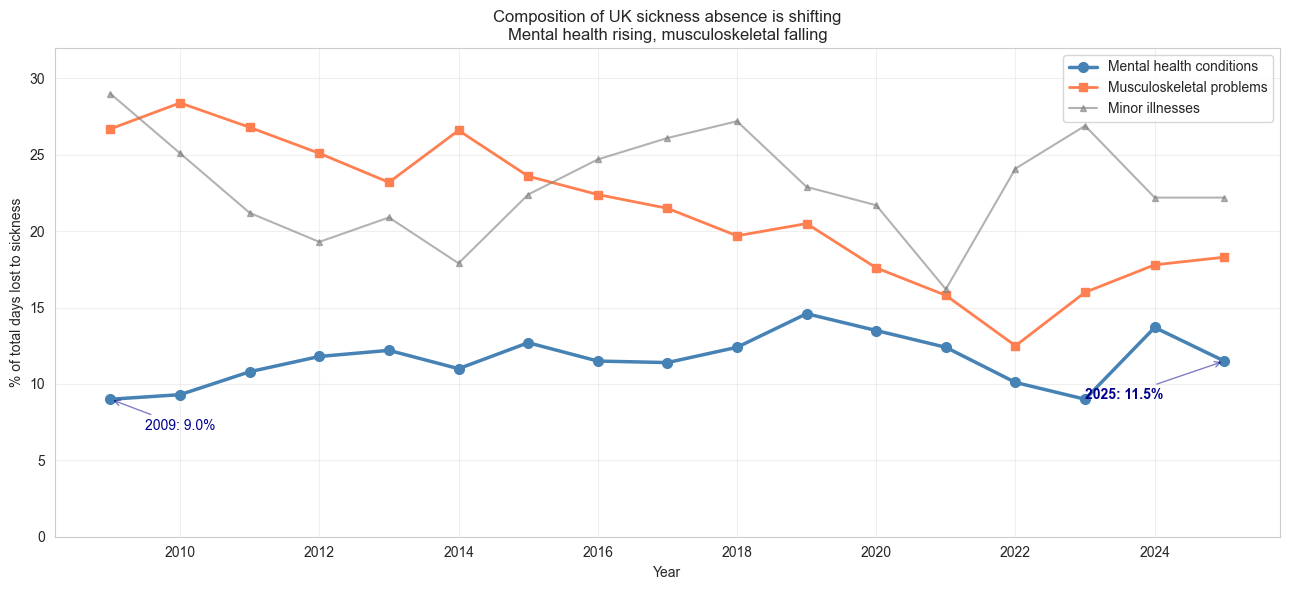


>>> KEY FINDINGS <<<
Mental health share of UK sickness absence:
  2009: 9.0%
  2025: 11.5%
  Peak (2019, pre-COVID): 14.6%
  Relative change since 2009: +28%

Musculoskeletal share (for contrast):
  2009: 26.7%
  2025: 18.3%
  Relative change since 2009: -31%


In [10]:
# Plot the mental health share of UK sickness absence over time
# Compare against musculoskeletal (which has fallen) for context

# Reshape to long format for plotting
year_cols = [c for c in absence_by_reason.columns if isinstance(c, int)]

# Get mental health and musculoskeletal time series
mh = absence_by_reason[absence_by_reason['reason'] == 'Mental health conditions'].iloc[0]
mh_series = mh[year_cols].sort_index()

msk = absence_by_reason[absence_by_reason['reason'] == 'Musculoskeletal problems'].iloc[0]
msk_series = msk[year_cols].sort_index()

minor = absence_by_reason[absence_by_reason['reason'] == 'Minor illnesses'].iloc[0]
minor_series = minor[year_cols].sort_index()

# Plot
fig, ax = plt.subplots(figsize=(13, 6))

years = mh_series.index.tolist()
ax.plot(years, mh_series.values, marker='o', linewidth=2.5, color='steelblue', 
        markersize=7, label='Mental health conditions')
ax.plot(years, msk_series.values, marker='s', linewidth=2, color='coral', 
        markersize=6, label='Musculoskeletal problems')
ax.plot(years, minor_series.values, marker='^', linewidth=1.5, color='gray', 
        alpha=0.6, markersize=5, label='Minor illnesses')

# Annotate the headline finding
ax.annotate(f'2009: {mh_series[2009]}%',
            xy=(2009, mh_series[2009]),
            xytext=(2009.5, mh_series[2009] - 2),
            fontsize=10, color='darkblue',
            arrowprops=dict(arrowstyle='->', color='darkblue', alpha=0.5))

ax.annotate(f'2025: {mh_series[2025]}%',
            xy=(2025, mh_series[2025]),
            xytext=(2023, mh_series[2025] - 2.5),
            fontsize=10, color='darkblue', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='darkblue', alpha=0.5))

ax.set_xlabel('Year')
ax.set_ylabel('% of total days lost to sickness')
ax.set_title('Composition of UK sickness absence is shifting\nMental health rising, musculoskeletal falling')
ax.legend(loc='upper right')
ax.set_ylim(0, 32)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / 'ons_mental_health_share.png', dpi=150, bbox_inches='tight')
plt.show()

# Key numbers for documentation
print("\n>>> KEY FINDINGS <<<")
print(f"Mental health share of UK sickness absence:")
print(f"  2009: {mh_series[2009]}%")
print(f"  2025: {mh_series[2025]}%")
print(f"  Peak (2019, pre-COVID): {mh_series[2019]}%")
print(f"  Relative change since 2009: +{((mh_series[2025] / mh_series[2009] - 1) * 100):.0f}%")
print(f"\nMusculoskeletal share (for contrast):")
print(f"  2009: {msk_series[2009]}%")
print(f"  2025: {msk_series[2025]}%")
print(f"  Relative change since 2009: {((msk_series[2025] / msk_series[2009] - 1) * 100):.0f}%")

In [11]:
# Load Table 10 — Absence rate by long-term health condition status, 1997-2025
# Likely structured: years in rows, columns are LTHC categories
raw_10 = pd.read_excel(SICKNESS_PATH, sheet_name='Table 10', header=None)
print(f"Shape: {raw_10.shape}")
print(f"\nFirst 8 rows × all cols:")
print(raw_10.iloc[:8])

Shape: (33, 3)

First 8 rows × all cols:
                                                   0                                                  1                                                  2
0  Worksheet 10: Sickness absence rate [note 1,2]...                                                NaN                                                NaN
1  This worksheet contains one table.  Some cells...                                                NaN                                                NaN
2  Source: Labour Force Survey person datasets [n...                                                NaN                                                NaN
3                                               Year  Sickness absence rate\nlong-term health condit...  Sickness absence rate\nno long-term health con...
4                                               1997                                                  7                                                2.2
5                            

In [12]:
# Load Table 10 — Absence rate by long-term health condition status, 1997-2025
lthc = pd.read_excel(SICKNESS_PATH, sheet_name='Table 10', skiprows=3)
lthc.columns = ['year', 'rate_with_lthc', 'rate_without_lthc']

# Clean
lthc = lthc[pd.to_numeric(lthc['year'], errors='coerce').notna()].copy()
lthc['year'] = lthc['year'].astype(int)
lthc['rate_with_lthc'] = pd.to_numeric(lthc['rate_with_lthc'])
lthc['rate_without_lthc'] = pd.to_numeric(lthc['rate_without_lthc'])

# Compute the gap (ratio)
lthc['ratio'] = lthc['rate_with_lthc'] / lthc['rate_without_lthc']

print(f"Records: {len(lthc)}")
print(f"Years: {lthc['year'].min()} – {lthc['year'].max()}")
print(f"\nFirst 3 years:")
print(lthc.head(3).to_string(index=False))
print(f"\nLast 5 years:")
print(lthc.tail(5).to_string(index=False))

latest = lthc.iloc[-1]
print(f"\n>>> KEY CALIBRATION NUMBERS <<<")
print(f"Latest year ({latest['year']}):")
print(f"  Employees WITH long-term health condition:    {latest['rate_with_lthc']}% absence")
print(f"  Employees WITHOUT long-term health condition: {latest['rate_without_lthc']}% absence")
print(f"  Ratio: {latest['ratio']:.1f}× higher for LTHC employees")

Records: 26
Years: 1997 – 2025

First 3 years:
 year  rate_with_lthc  rate_without_lthc    ratio
 1997             7.0                2.2 3.181818
 1998             6.2                2.2 2.818182
 1999             6.2                2.2 2.818182

Last 5 years:
 year  rate_with_lthc  rate_without_lthc    ratio
 2018             4.4                1.1 4.000000
 2022             4.9                1.6 3.062500
 2023             4.6                1.1 4.181818
 2024             4.0                1.0 4.000000
 2025             4.0                1.0 4.000000

>>> KEY CALIBRATION NUMBERS <<<
Latest year (2025.0):
  Employees WITH long-term health condition:    4.0% absence
  Employees WITHOUT long-term health condition: 1.0% absence
  Ratio: 4.0× higher for LTHC employees


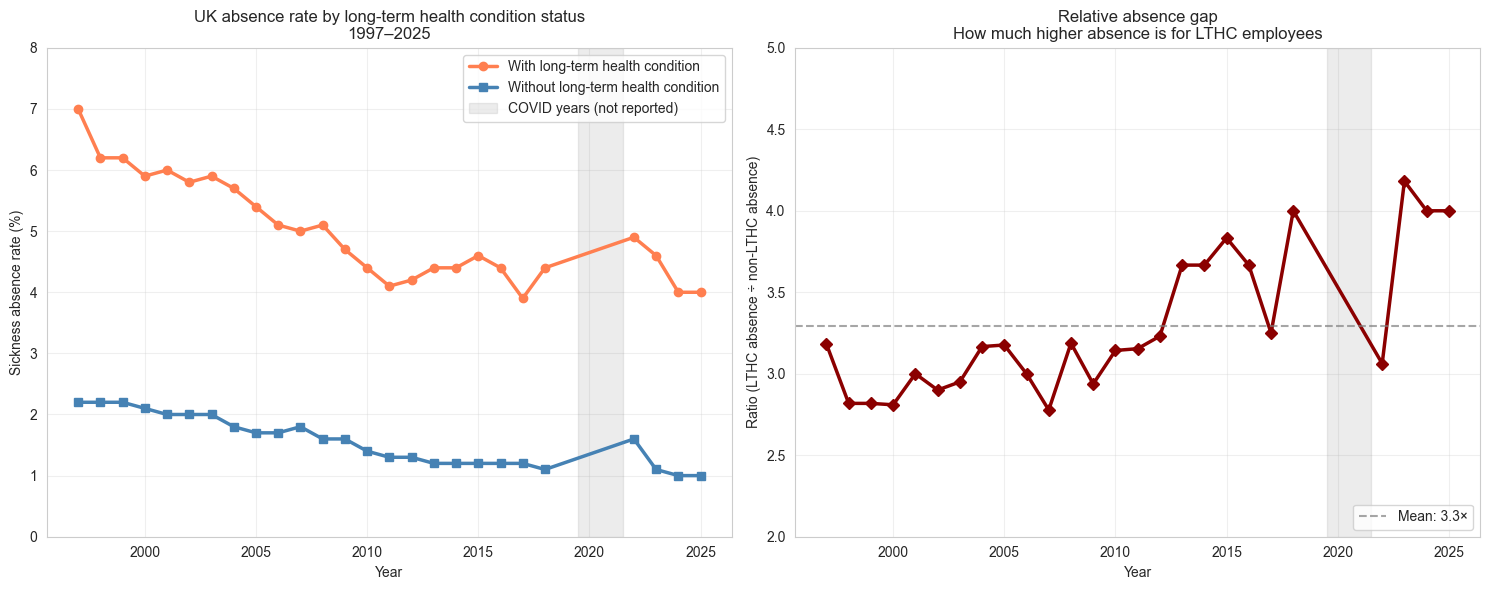


>>> WELLBEING-IMPACT VALIDATOR <<<
Current UK absence rate, by long-term health status (2025):
  With LTHC:    4.0%
  Without LTHC: 1.0%
  Gap: 3.0 percentage points
  Ratio: 4.0×

Historical context:
  1997 ratio: 3.2×
  2025 ratio: 4.0×
  → The relative absence gap has widened by 26% since 1997


In [14]:
# Plot absence rate by LTHC status, with the ratio line
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left panel: absolute rates
ax1.plot(lthc['year'], lthc['rate_with_lthc'], 
         marker='o', linewidth=2.5, color='coral', markersize=6,
         label='With long-term health condition')
ax1.plot(lthc['year'], lthc['rate_without_lthc'], 
         marker='s', linewidth=2.5, color='steelblue', markersize=6,
         label='Without long-term health condition')
ax1.axvspan(2019.5, 2021.5, alpha=0.15, color='gray', label='COVID years (not reported)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Sickness absence rate (%)')
ax1.set_title('UK absence rate by long-term health condition status\n1997–2025')
ax1.legend(loc='upper right')
ax1.grid(alpha=0.3)
ax1.set_ylim(0, 8)

# Right panel: the ratio (how much higher is LTHC absence)
ax2.plot(lthc['year'], lthc['ratio'], 
         marker='D', linewidth=2.5, color='darkred', markersize=6)
ax2.axhline(y=lthc['ratio'].mean(), color='gray', linestyle='--', 
            alpha=0.7, label=f"Mean: {lthc['ratio'].mean():.1f}×")
ax2.axvspan(2019.5, 2021.5, alpha=0.15, color='gray')
ax2.set_xlabel('Year')
ax2.set_ylabel('Ratio (LTHC absence ÷ non-LTHC absence)')
ax2.set_title('Relative absence gap\nHow much higher absence is for LTHC employees')
ax2.legend(loc='lower right')
ax2.grid(alpha=0.3)
ax2.set_ylim(2, 5)

plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / 'ons_absence_by_lthc.png', dpi=150, bbox_inches='tight')
plt.show()

# Headline numbers
latest = lthc.iloc[-1]
print(f"\n>>> WELLBEING-IMPACT VALIDATOR <<<")
print(f"Current UK absence rate, by long-term health status (2025):")
print(f"  With LTHC:    {latest['rate_with_lthc']}%")
print(f"  Without LTHC: {latest['rate_without_lthc']}%")
print(f"  Gap: {latest['rate_with_lthc'] - latest['rate_without_lthc']:.1f} percentage points")
print(f"  Ratio: {latest['ratio']:.1f}×")
print(f"\nHistorical context:")
print(f"  1997 ratio: {lthc.iloc[0]['ratio']:.1f}×")
print(f"  2025 ratio: {latest['ratio']:.1f}×")
print(f"  → The relative absence gap has widened by {((latest['ratio'] / lthc.iloc[0]['ratio'] - 1) * 100):.0f}% since 1997")

In [15]:
# Load Table 21 — Absence rate by industry sector, 2019-2025
raw_21 = pd.read_excel(SICKNESS_PATH, sheet_name='Table 21', header=None)
print(f"Shape: {raw_21.shape}")
print(f"\nFirst 8 rows × first 8 cols:")
print(raw_21.iloc[:8, :8])

Shape: (22, 9)

First 8 rows × first 8 cols:
                                                   0                                 1                                 2                                 3                                 4  \
0  Worksheet 21: Sickness absence rate [note 1,2]...                               NaN                               NaN                               NaN                               NaN   
1  This worksheet contains one table.  Some cells...                               NaN                               NaN                               NaN                               NaN   
2  Source: Labour Force Survey person datasets [n...                               NaN                               NaN                               NaN                               NaN   
3  Some shorthand is used in these tables, [u]=Es...                               NaN                               NaN                               NaN                               Na

In [18]:
# Load Table 21 — Absence rate by industry sector, 2019-2025
raw_21 = pd.read_excel(SICKNESS_PATH, sheet_name='Table 21', header=None)

# Take rows 6 onwards as data
industry = raw_21.iloc[6:].copy().reset_index(drop=True)

# We know the column order from the previous output:
# 0=industry, 1=2025, 2=2024, 3=2023, 4=2022, 5=2021, 6=2020, 7=2019, 8=Notes
industry.columns = ['industry', 2025, 2024, 2023, 2022, 2021, 2020, 2019, 'notes']

# Drop the notes column (don't need it)
industry = industry.drop(columns='notes')

# Drop rows with no industry value
industry = industry[industry['industry'].notna()].copy()
industry['industry'] = industry['industry'].astype(str).str.strip()

# Drop footnote/total rows
industry = industry[~industry['industry'].str.lower().str.contains(
    'total|note|all industries|nan', na=False, regex=True
)]

# Convert year columns to numeric (handles [u] shorthand → NaN)
year_cols_21 = [2025, 2024, 2023, 2022, 2021, 2020, 2019]
for col in year_cols_21:
    industry[col] = pd.to_numeric(industry[col], errors='coerce')

print(f"Industries captured: {len(industry)}")
print(f"\nFull industry table sorted by 2025 absence rate (highest first):\n")
print(industry.sort_values(2025, ascending=False).to_string(index=False))

Industries captured: 15

Full industry table sorted by 2025 absence rate (highest first):

                                          industry  2025  2024  2023  2022  2021  2020  2019
                            H: Transport & storage   3.3   2.7   2.4   2.6   3.2   2.5   2.0
          Q: Human health & social work activities   3.0   2.9   3.6   4.2   3.5   3.0   2.9
            B,D,E: Mining, energy and water supply   2.9   2.1   2.1   3.1   2.9   2.0   2.4
        O: Public admin & defence; social security   2.4   2.2   2.7   2.7   2.6   2.1   2.4
                                  C: Manufacturing   2.2   2.1   2.0   2.4   1.8   1.9   1.8
                                      P: Education   2.1   2.4   2.7   3.0   2.2   2.2   2.3
   G: Wholesale, retail & repair of motor vehicles   2.0   1.9   2.2   3.0   2.1   1.7   1.9
              N: Administrative & support services   2.0   1.7   2.7   2.1   2.3   2.1   2.0
                         L: Real estate activities   1.8   1.1   2.5   1

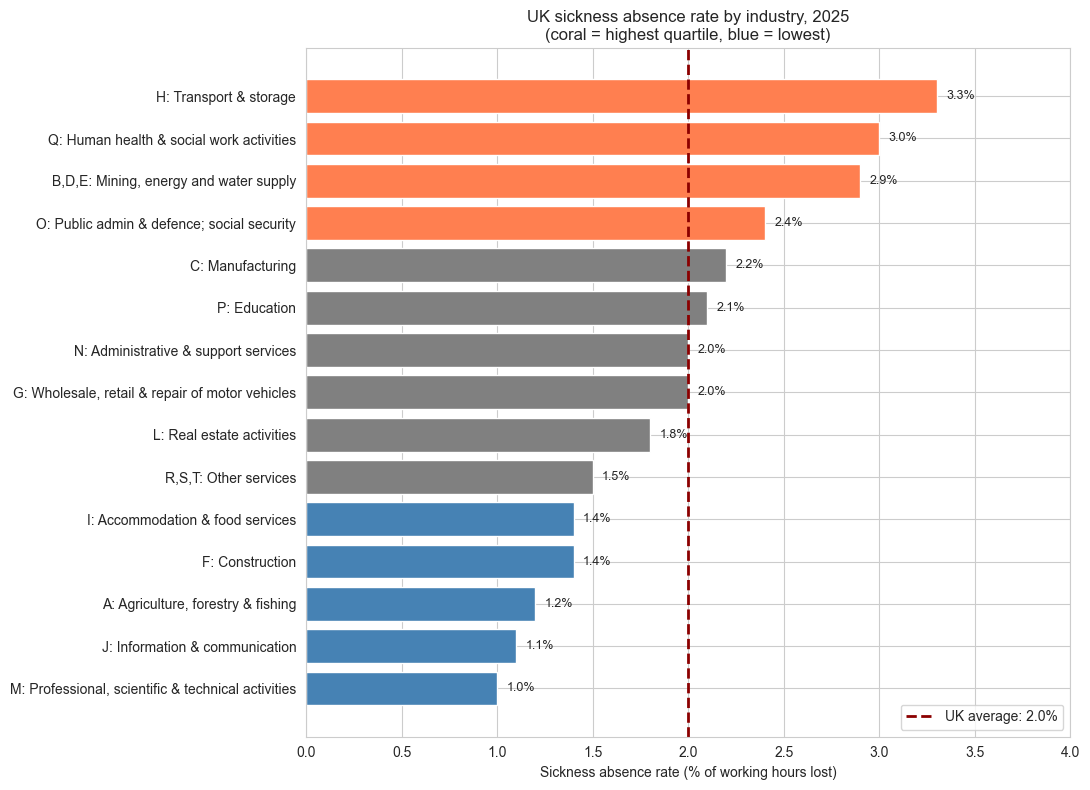


>>> INDUSTRY ABSENCE CALIBRATION (2025) <<<
UK average absence rate: 2.0%

Highest absence: H: Transport & storage at 3.3%
Lowest absence:  M: Professional, scientific & technical activities at 1.0%
Top-to-bottom gap: 3.3×

Knowledge-work sectors (Wellmatch target):
  Professional services: 1.0%
  Information & communication: 1.1%


In [19]:
# Plot UK absence rate by industry, 2025
fig, ax = plt.subplots(figsize=(11, 8))

industry_sorted = industry.sort_values(2025, ascending=True)

# Colour bars by quartile of absence rate
q1, q3 = industry_sorted[2025].quantile([0.25, 0.75])
colours = ['coral' if v >= q3 else 'steelblue' if v <= q1 else 'gray'
           for v in industry_sorted[2025]]

bars = ax.barh(industry_sorted['industry'], industry_sorted[2025], color=colours)

# UK average reference line
uk_average = 2.0  # from Table 1, 2025
ax.axvline(uk_average, color='darkred', linestyle='--', linewidth=2, 
           label=f'UK average: {uk_average}%')

# Annotate each bar with its value
for bar, val in zip(bars, industry_sorted[2025]):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2, 
            f'{val}%', va='center', fontsize=9)

ax.set_xlabel('Sickness absence rate (% of working hours lost)')
ax.set_title('UK sickness absence rate by industry, 2025\n(coral = highest quartile, blue = lowest)')
ax.legend(loc='lower right')
ax.set_xlim(0, 4.0)

plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / 'ons_absence_by_industry.png', dpi=150, bbox_inches='tight')
plt.show()

# Print headline numbers
print("\n>>> INDUSTRY ABSENCE CALIBRATION (2025) <<<")
print(f"UK average absence rate: 2.0%")
print(f"\nHighest absence: {industry_sorted.iloc[-1]['industry']} at {industry_sorted.iloc[-1][2025]}%")
print(f"Lowest absence:  {industry_sorted.iloc[0]['industry']} at {industry_sorted.iloc[0][2025]}%")
print(f"Top-to-bottom gap: {industry_sorted.iloc[-1][2025] / industry_sorted.iloc[0][2025]:.1f}×")
print(f"\nKnowledge-work sectors (Wellmatch target):")
print(f"  Professional services: {industry_sorted[industry_sorted['industry'].str.contains('Professional', na=False)][2025].values[0]}%")
print(f"  Information & communication: {industry_sorted[industry_sorted['industry'].str.contains('Information', na=False)][2025].values[0]}%")

---

## Part 1 summary — UK sickness absence calibration

### Headline numbers (2025)
- **UK overall absence rate:** 2.0%
- **Days lost per worker per year:** 4.4
- **Total UK days lost annually:** 149 million
- **Long-term-illness employees:** 4.0% absence rate (4× higher than non-LTHC at 1.0%)

### Composition shift (the Wellmatch story)
- Mental health share of UK absence: **9.0% (2009) → 11.5% (2025)** = +28% relative increase
- Musculoskeletal share: **26.7% (2009) → 18.3% (2025)** = -31% relative decrease
- Mental health peaked at 14.6% in 2019 (pre-pandemic); volatile since

### Industry pattern (2025)
- **Highest absence:** Transport & storage (3.3%), Human health & social work (3.0%), Mining/energy (2.9%)
- **Lowest absence:** Professional, scientific & technical (1.0%), Information & communication (1.1%)
- **3.3× gap from highest to lowest sector**
- High-absence sectors share: physical work, shift patterns, high demands
- Low-absence sectors share: knowledge work, schedule autonomy

### What this means for Wellmatch
1. **The right framing:** "Your visible absence looks low; your hidden mental-health absence is the rising problem"
2. **LTHC = 4× absence is empirical proof that wellbeing measurably affects business cost** — anchors all ROI claims

---

## Part 2: ASHE — UK earnings

ASHE Selected Estimates, 1997–2025. We extract:
- Median weekly pay for all employees and full-time employees (Table 1, 2)
- Pay by industry (Table 7_SIC07) — to cross-reference against Part 1's absence-by-industry
- Pay by occupation (Table 10_SOC20)

**Purpose:** Convert absence days into £ cost. Combined with Part 1's "4.4 days per worker per year", median daily wage gives us the annual £ cost of UK sickness absence per employee.

In [20]:
# Inspect ASHE Table 1 — All employees' pay and paid hours by sex, UK, 1997-2025
raw_t1 = pd.read_excel(ASHE_PATH, sheet_name='Table 1', header=None)
print(f"Shape: {raw_t1.shape}")
print(f"\nFirst 12 rows × first 8 cols:")
print(raw_t1.iloc[:12, :8])

Shape: (84, 39)

First 12 rows × first 8 cols:
                                     0                                                  1       2       3        4        5        6        7
0                             Table 1   Alla employees' pay and paid hours by sex, Uni...     NaN     NaN      NaN      NaN      NaN      NaN
1                                  NaN                                                NaN     NaN     NaN      NaN      NaN      NaN      NaN
2                                  NaN                                                NaN  1997.0  1998.0   1999.0   2000.0   2001.0   2002.0
3                                  NaN                                                NaN     NaN     NaN      NaN      NaN      NaN      NaN
4                                  NaN                                                All     NaN     NaN      NaN      NaN      NaN      NaN
5                                  NaN                                                NaN     NaN    

In [21]:
# Extract median weekly earnings for ALL employees, 1997-2025
# Row 9 has the values, Row 2 has the years
years_row = raw_t1.iloc[2].tolist()
weekly_row = raw_t1.iloc[9].tolist()

# Pair them up, skipping the first two columns (label, NaN)
pairs = []
for i in range(2, len(years_row)):
    year = years_row[i]
    pay = weekly_row[i]
    if pd.notna(year) and pd.notna(pay):
        try:
            pairs.append({
                'year': int(year),
                'median_weekly_pay_gbp': float(pay)
            })
        except (ValueError, TypeError):
            continue

ashe_weekly = pd.DataFrame(pairs)

print(f"Records: {len(ashe_weekly)}")
print(f"Years covered: {ashe_weekly['year'].min()} – {ashe_weekly['year'].max()}")
print(f"\nFirst 3 years:")
print(ashe_weekly.head(3).to_string(index=False))
print(f"\nLast 5 years:")
print(ashe_weekly.tail(5).to_string(index=False))

latest = ashe_weekly.iloc[-1]
earliest = ashe_weekly.iloc[0]
print(f"\n>>> KEY CALIBRATION NUMBERS <<<")
print(f"Latest year ({latest['year']}): UK median gross weekly pay = £{latest['median_weekly_pay_gbp']:.2f}")
print(f"Daily wage (÷ 5): £{latest['median_weekly_pay_gbp']/5:.2f}")
print(f"Annual gross (× 52): £{latest['median_weekly_pay_gbp']*52:,.0f}")
print(f"\nGrowth since {earliest['year']}: £{earliest['median_weekly_pay_gbp']:.0f} → £{latest['median_weekly_pay_gbp']:.0f}")
print(f"({(latest['median_weekly_pay_gbp']/earliest['median_weekly_pay_gbp'] - 1)*100:.0f}% nominal growth over {latest['year'] - earliest['year']} years)")

Records: 28
Years covered: 1997 – 2025

First 3 years:
 year  median_weekly_pay_gbp
 1997                  268.9
 1998                  280.2
 1999                  290.0

Last 5 years:
 year  median_weekly_pay_gbp
 2021                  504.4
 2022                  533.7
 2023                  574.9
 2024                  613.5
 2025                  642.5

>>> KEY CALIBRATION NUMBERS <<<
Latest year (2025.0): UK median gross weekly pay = £642.50
Daily wage (÷ 5): £128.50
Annual gross (× 52): £33,410

Growth since 1997.0: £269 → £642
(139% nominal growth over 28.0 years)


In [22]:
# Headline UK ROI calculation
# Combines numbers from Tables 3 (sickness absence) and ASHE Table 1 (earnings)

UK_DAYS_LOST_PER_WORKER = 4.4      # from Table 3, 2025
UK_MEDIAN_WEEKLY_PAY = 642.50      # from ASHE Table 1, 2025
UK_MEDIAN_DAILY_PAY = UK_MEDIAN_WEEKLY_PAY / 5

# Cost of absence per employee, per year
annual_cost_per_employee = UK_DAYS_LOST_PER_WORKER * UK_MEDIAN_DAILY_PAY

print("=" * 60)
print(">>> HEADLINE UK ROI CALIBRATION (2025) <<<")
print("=" * 60)
print(f"\nInputs:")
print(f"  Days lost per UK worker (ONS Table 3):       {UK_DAYS_LOST_PER_WORKER}")
print(f"  Median weekly pay (ASHE Table 1):             £{UK_MEDIAN_WEEKLY_PAY:.2f}")
print(f"  Implied daily pay (÷ 5):                      £{UK_MEDIAN_DAILY_PAY:.2f}")
print(f"\nDirect £ cost of UK sickness absence:")
print(f"  Per employee, per year:  £{annual_cost_per_employee:.0f}")
print(f"  Per 100 employees:       £{annual_cost_per_employee * 100:,.0f}")
print(f"  Per 1,000 employees:     £{annual_cost_per_employee * 1000:,.0f}")
print(f"  Per 10,000 employees:    £{annual_cost_per_employee * 10000:,.0f}")
print(f"\nIf Wellmatch reduces absence by 10%:")
print(f"  Saving per employee/year:   £{annual_cost_per_employee * 0.10:.0f}")
print(f"  Saving per 1,000 employees: £{annual_cost_per_employee * 0.10 * 1000:,.0f}")
print(f"\nNotes:")
print(f"  - 'Direct cost' = paid wage during absence")
print(f"  - Excludes replacement labour, lost productivity, management time")
print(f"  - Total cost typically 2-3× direct cost (CIPD estimate)")

>>> HEADLINE UK ROI CALIBRATION (2025) <<<

Inputs:
  Days lost per UK worker (ONS Table 3):       4.4
  Median weekly pay (ASHE Table 1):             £642.50
  Implied daily pay (÷ 5):                      £128.50

Direct £ cost of UK sickness absence:
  Per employee, per year:  £565
  Per 100 employees:       £56,540
  Per 1,000 employees:     £565,400
  Per 10,000 employees:    £5,654,000

If Wellmatch reduces absence by 10%:
  Saving per employee/year:   £57
  Saving per 1,000 employees: £56,540

Notes:
  - 'Direct cost' = paid wage during absence
  - Excludes replacement labour, lost productivity, management time
  - Total cost typically 2-3× direct cost (CIPD estimate)


In [23]:
# Inspect ASHE Table 7_SIC07 — Full-time employees' pay by industry sector, 2008-2025
raw_t7 = pd.read_excel(ASHE_PATH, sheet_name='Table 7_SIC07', header=None)
print(f"Shape: {raw_t7.shape}")
print(f"\nFirst 12 rows × first 6 cols:")
print(raw_t7.iloc[:12, :6])

Shape: (114, 31)

First 12 rows × first 6 cols:
                                                    0                                                  1                                  2        3      4           5
0                                     Table 7_SIC07    Full-timea,b employees' pay by industry sector...                                NaN      NaN    NaN         NaN
1                                                 NaN                                                NaN                                NaN      NaN    NaN         NaN
2                                                 NaN                                                NaN                               2008   2009.0   2010  2011 soc00
3                                                 NaN                                                NaN                                NaN      NaN    NaN         NaN
4                                                 NaN                                                NaN  Median

In [26]:
# The last 3 rows are weekly pay (around £1,000) leaking into our annual figures
# Filter to keep only annual-scale numbers (>£20,000)

ashe_industry_clean = ashe_industry[
    ashe_industry['median_annual_pay_2025'] > 20000
].copy()

# Also drop any duplicates that might be hiding
ashe_industry_clean = ashe_industry_clean.drop_duplicates(subset='industry', keep='first')

print(f"Industries after cleanup: {len(ashe_industry_clean)}")
print(f"\nFinal pay-by-industry table (2025), sorted highest to lowest:\n")
print(ashe_industry_clean.sort_values('median_annual_pay_2025', ascending=False).to_string(index=False))

Industries after cleanup: 21

Final pay-by-industry table (2025), sorted highest to lowest:

                                                            industry  median_annual_pay_2025
                                  Financial and insurance activities                 58488.0
                 Electricity, gas, steam and air conditioning supply                 55469.0
                                       Information and Communication                 52264.0
                                                Mining and quarrying                 50943.0
                   Professional, scientific and technical activities                 46208.0
                                                        Construction                 43100.0
             Activities Of Extraterritorial Organisations And Bodies                 40987.0
       Public administration and defence; compulsory social security                 40879.0
 Water supply; sewerage, waste management and remediation activities  

In [27]:
# Map ASHE industry names → SIC07 letter codes used in Part 1 absence table
# This is a manual mapping because ASHE and ONS use slightly different labels

ashe_to_sic = {
    'Agriculture, forestry and fishing': 'A: Agriculture, forestry & fishing',
    'Mining and quarrying': 'B,D,E: Mining, energy and water supply',
    'Electricity, gas, steam and air conditioning supply': 'B,D,E: Mining, energy and water supply',
    'Water supply; sewerage, waste management and remediation activities': 'B,D,E: Mining, energy and water supply',
    'Manufacturing': 'C: Manufacturing',
    'Construction': 'F: Construction',
    'Wholesale and retail trade; repair of motor vehicles and motorcycles': 'G: Wholesale, retail & repair of motor vehicles',
    'Transportation and storage': 'H: Transport & storage',
    'Accommodation and food service activities': 'I: Accommodation & food services',
    'Information and Communication': 'J: Information & communication',
    'Financial and insurance activities': None,  # No matching absence sector (lumped elsewhere)
    'Real estate activities': 'L: Real estate activities',
    'Professional, scientific and technical activities': 'M: Professional, scientific & technical activities',
    'Administrative and support service activities': 'N: Administrative & support services',
    'Public administration and defence; compulsory social security': 'O: Public admin & defence; social security',
    'Education': 'P: Education',
    'Human health and social work activities': 'Q: Human health & social work activities',
    'Arts, entertainment and recreation': 'R,S,T: Other services',
    'Other service activities': 'R,S,T: Other services',
    'Activities of Households as Employers': 'R,S,T: Other services',
    'Activities Of Extraterritorial Organisations And Bodies': None,
}

# Apply mapping
ashe_industry_clean['sic_letter'] = ashe_industry_clean['industry'].map(ashe_to_sic)

# For sectors where multiple ASHE rows map to one SIC letter (e.g. B,D,E),
# take the average pay
pay_by_sic = ashe_industry_clean.dropna(subset=['sic_letter']).groupby('sic_letter').agg(
    median_annual_pay_2025=('median_annual_pay_2025', 'mean'),
    n_ashe_rows=('industry', 'count')
).reset_index()

print(f"SIC letters with both pay and absence: {len(pay_by_sic)}\n")
print(pay_by_sic.sort_values('median_annual_pay_2025', ascending=False).to_string(index=False))

# Now merge with the absence-by-industry table from Part 1
combined = pd.merge(
    industry[['industry', 2025]].rename(columns={'industry': 'sic_letter', 2025: 'absence_rate_2025'}),
    pay_by_sic[['sic_letter', 'median_annual_pay_2025']],
    on='sic_letter',
    how='inner'
)

print(f"\n\nMerged table — pay vs absence by industry (2025):\n")
print(combined.sort_values('median_annual_pay_2025', ascending=False).to_string(index=False))

# Quick correlation
corr = combined['median_annual_pay_2025'].corr(combined['absence_rate_2025'])
print(f"\n>>> Pearson correlation: pay vs absence at sector level = {corr:.3f}")
print(f"Interpretation: {'low pay → high absence' if corr < -0.2 else 'high pay → high absence' if corr > 0.2 else 'no clear relationship'}")

SIC letters with both pay and absence: 15

                                        sic_letter  median_annual_pay_2025  n_ashe_rows
                    J: Information & communication            52264.000000            1
            B,D,E: Mining, energy and water supply            49050.000000            3
M: Professional, scientific & technical activities            46208.000000            1
                                   F: Construction            43100.000000            1
        O: Public admin & defence; social security            40879.000000            1
                            H: Transport & storage            40056.000000            1
                                      P: Education            39999.000000            1
                                  C: Manufacturing            38956.000000            1
                         L: Real estate activities            36565.000000            1
              N: Administrative & support services            36109.000000   

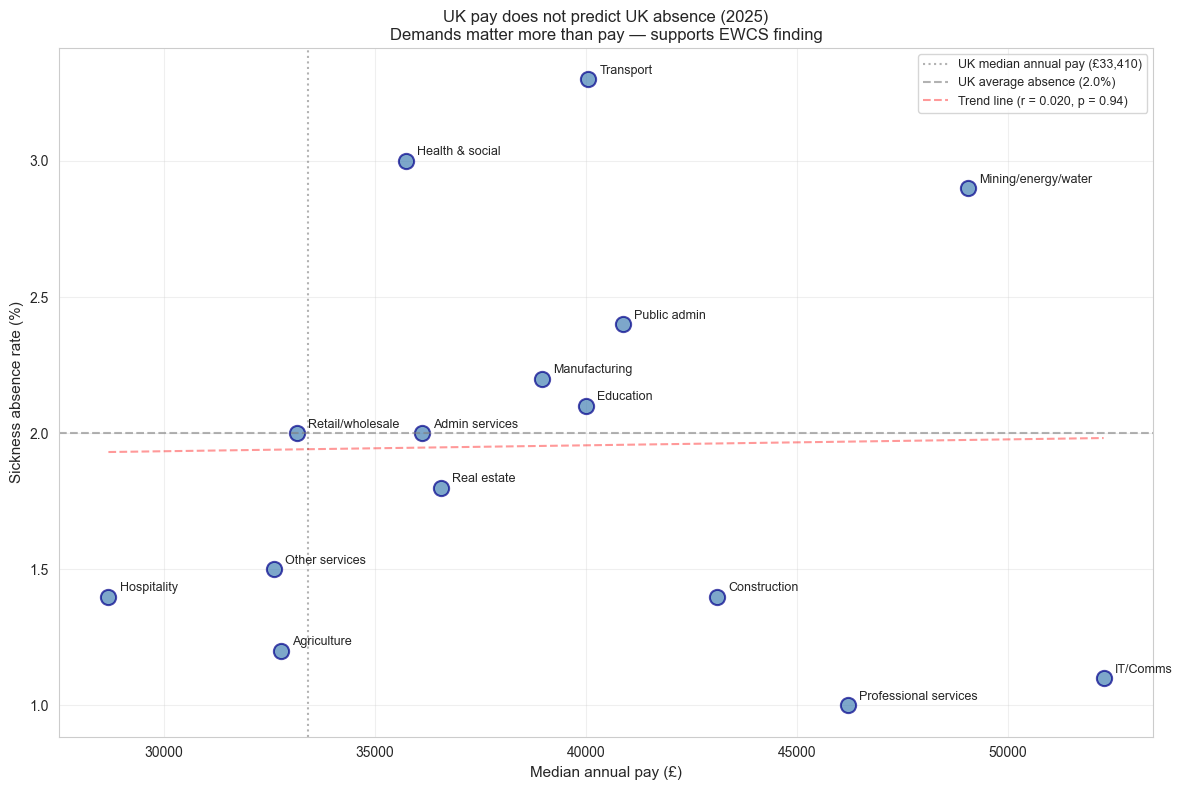


>>> KEY FINDING <<<
UK sector-level correlation: pay vs absence = 0.020 (p = 0.94, n = 15)
Pay does NOT predict sickness absence at the industry level.
This triangulates with EWCS finding that pay is not in the top predictors of intent-to-leave.


In [28]:
# Scatter: pay vs absence by UK industry, 2025
fig, ax = plt.subplots(figsize=(12, 8))

# Scatter
ax.scatter(combined['median_annual_pay_2025'], combined['absence_rate_2025'],
           s=120, alpha=0.7, color='steelblue', edgecolor='darkblue', linewidth=1.5)

# Label each point with shortened industry name
for _, row in combined.iterrows():
    label = row['sic_letter'].split(':')[1].strip() if ':' in row['sic_letter'] else row['sic_letter']
    # Shorten very long labels
    if 'Public admin' in label:
        label = 'Public admin'
    elif 'Wholesale, retail' in label:
        label = 'Retail/wholesale'
    elif 'Professional' in label:
        label = 'Professional services'
    elif 'Mining' in label:
        label = 'Mining/energy/water'
    elif 'Human health' in label:
        label = 'Health & social'
    elif 'Accommodation' in label:
        label = 'Hospitality'
    elif 'Information' in label:
        label = 'IT/Comms'
    elif 'Agriculture' in label:
        label = 'Agriculture'
    elif 'Transport' in label:
        label = 'Transport'
    elif 'Real estate' in label:
        label = 'Real estate'
    elif 'Administrative' in label:
        label = 'Admin services'
    elif 'Other services' in label:
        label = 'Other services'
    elif 'Manufacturing' in label:
        label = 'Manufacturing'
    
    ax.annotate(label, 
                xy=(row['median_annual_pay_2025'], row['absence_rate_2025']),
                xytext=(8, 4), textcoords='offset points',
                fontsize=9)

# Reference lines
uk_avg_pay = ashe_weekly.iloc[-1]['median_weekly_pay_gbp'] * 52
ax.axvline(uk_avg_pay, color='gray', linestyle=':', alpha=0.6, label=f'UK median annual pay (£{uk_avg_pay:,.0f})')
ax.axhline(2.0, color='gray', linestyle='--', alpha=0.6, label='UK average absence (2.0%)')

# Compute the regression line (even though r ≈ 0)
from scipy.stats import linregress
slope, intercept, r_val, p_val, _ = linregress(
    combined['median_annual_pay_2025'], combined['absence_rate_2025']
)
x_range = np.array([combined['median_annual_pay_2025'].min(), 
                    combined['median_annual_pay_2025'].max()])
ax.plot(x_range, slope * x_range + intercept, 'r--', alpha=0.4, 
        label=f'Trend line (r = {r_val:.3f}, p = {p_val:.2f})')

ax.set_xlabel('Median annual pay (£)', fontsize=11)
ax.set_ylabel('Sickness absence rate (%)', fontsize=11)
ax.set_title('UK pay does not predict UK absence (2025)\nDemands matter more than pay — supports EWCS finding',
             fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / 'ons_pay_vs_absence_by_industry.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n>>> KEY FINDING <<<")
print(f"UK sector-level correlation: pay vs absence = {r_val:.3f} (p = {p_val:.2f}, n = {len(combined)})")
print(f"Pay does NOT predict sickness absence at the industry level.")
print(f"This triangulates with EWCS finding that pay is not in the top predictors of intent-to-leave.")

---

## Part 2 summary — ASHE earnings

### Calibration extracted
- **UK median weekly gross pay (2025):** £642.50
- **Implied daily pay:** £128.50
- **Implied annual gross:** £33,410
- 29-year nominal growth: 1997 £268.90 → 2025 £642.50 (+139%)

### The headline UK ROI number
**Direct annual cost of sickness absence per UK employee = 4.4 days × £128.50/day = £565**

For a 1,000-employee client: **£565,000/year direct cost**. A 10% reduction = **£57k/year saved**. Full cost (including replacement labour and lost productivity) typically 2–3× direct = £1,100–£1,700/employee/year.

### Pay vs absence by industry (key analytical finding)
**Pearson correlation: r = 0.020 (p = 0.94, n = 15 industries).**
**Pay does NOT predict UK absence at the sector level.** The trend line is flat. At any given pay band, absence rates vary 2–3× between industries — what differentiates them is work demands, not pay.

The four-quadrant pattern:
- **Low absence** sectors are knowledge work (IT, Professional Services) OR insecure low-pay work (Hospitality, Agriculture) — the latter likely under-reported / presenteeism
- **High absence** sectors are demanding work regardless of pay (Mining £49k, Transport £40k, Health £36k all show 2.9–3.3% absence)

### Triangulation with EWCS
EWCS at individual level: recognition and fair treatment predict intent-to-leave; pay does not.
ASHE × ONS at sector level: pay does not predict absence; work demands do.

**Two different datasets, two different outcomes — same conclusion: demands and recognition matter; pay does not.** Empirical foundation for Wellmatch's positioning against the dominant "pay them more" narrative.

---

## Part 3: HMRC PAYE Real Time Information (RTI)

HMRC PAYE RTI, May 2026 release. Administrative data based on actual UK payroll records — not a survey. Monthly time series back to ~2014.

**What we extract:**
- Sheet 1: Payrolled employees (UK) — total UK employee count over time
- Sheet 6: Employee flows (UK) — joiners, leavers, and net change (the UK turnover proxy)
- Sheet 2: Median pay (UK) — current monthly median pay

**Purpose:** Give us a UK turnover rate to triangulate against EWCS's 19.8% intent-to-leave figure. The gap between intent and behaviour is itself a finding.

In [29]:
# Inspect RTI Sheet 6 — Employee flows (UK)
raw_rti6 = pd.read_excel(RTI_PATH, sheet_name='6. Employee flows (UK)', header=None)
print(f"Shape: {raw_rti6.shape}")
print(f"\nFirst 12 rows × all cols:")
print(raw_rti6.iloc[:12])

Shape: (118, 4)

First 12 rows × all cols:
                                                0                                                  1         2                              3
0   6. Flows of payrolled employees from PAYE RTI                                                NaN       NaN                            NaN
1     UK, all industries, not seasonally adjusted                                                NaN       NaN                            NaN
2                                             NaN                                                NaN       NaN                            NaN
3                                           Units                                Payrolled employees       NaN                            NaN
4                                Additional notes  Early estimates for inflows and outflows have ...       NaN                            NaN
5                                             NaN                                                NaN     

In [30]:
# Load Sheet 6 — Employee flows (UK)
# Data starts at row 7 (after row 6 headers); columns are Date, Inflows, Outflows, Change
rti_flows = pd.read_excel(RTI_PATH, sheet_name='6. Employee flows (UK)', skiprows=7, header=None)
rti_flows.columns = ['month', 'inflows', 'outflows', 'net_change']

# Drop any empty rows
rti_flows = rti_flows.dropna(subset=['month']).copy()

# Convert month string to datetime
rti_flows['date'] = pd.to_datetime(rti_flows['month'], format='%B %Y', errors='coerce')
rti_flows = rti_flows.dropna(subset=['date']).reset_index(drop=True)

# Make sure flow columns are numeric
for col in ['inflows', 'outflows', 'net_change']:
    rti_flows[col] = pd.to_numeric(rti_flows[col], errors='coerce')

print(f"Records: {len(rti_flows)}")
print(f"Period: {rti_flows['date'].min().strftime('%B %Y')} – {rti_flows['date'].max().strftime('%B %Y')}")
print(f"\nFirst 3 months:")
print(rti_flows[['month', 'inflows', 'outflows', 'net_change']].head(3).to_string(index=False))
print(f"\nLast 3 months:")
print(rti_flows[['month', 'inflows', 'outflows', 'net_change']].tail(3).to_string(index=False))

Records: 111
Period: January 2017 – March 2026

First 3 months:
        month  inflows  outflows  net_change
 January 2017   515656    699811     -184155
February 2017   625181    603426       21755
   March 2017   640523    551460       89063

Last 3 months:
        month  inflows  outflows  net_change
 January 2026   458470    668497     -210027
February 2026   536239    569247      -33008
   March 2026   551222    542457        8765


In [31]:
# Load Sheet 1 — Payrolled employees (UK), monthly time series
# First inspect to see structure
raw_rti1 = pd.read_excel(RTI_PATH, sheet_name='1. Payrolled employees (UK)', header=None)
print(f"Shape: {raw_rti1.shape}")
print(f"\nFirst 10 rows × all cols:")
print(raw_rti1.iloc[:10])

Shape: (148, 3)

First 10 rows × all cols:
                                             0                    1                         2
0   1. Payrolled employee counts from PAYE RTI                  NaN                       NaN
1  UK, all industries, not seasonally adjusted                  NaN                       NaN
2                                          NaN                  NaN                       NaN
3                                        Units  Payrolled employees                       NaN
4                                          NaN                  NaN                       NaN
5                                         Date  Payrolled employees  Change on previous month
6                                    July 2014             26893195                       NaN
7                                  August 2014             26864533                    -28662
8                               September 2014             26944287                     79754
9                

In [32]:
# Load Sheet 1 — UK payrolled employees, monthly time series
# Data starts at row 6 (after row 5 headers)
rti_count = pd.read_excel(RTI_PATH, sheet_name='1. Payrolled employees (UK)', skiprows=6, header=None)
rti_count.columns = ['month', 'payrolled_employees', 'change_on_prev']

# Drop empty rows
rti_count = rti_count.dropna(subset=['month']).copy()

# Convert to datetime
rti_count['date'] = pd.to_datetime(rti_count['month'], format='%B %Y', errors='coerce')
rti_count = rti_count.dropna(subset=['date']).reset_index(drop=True)

# Make sure count columns are numeric
rti_count['payrolled_employees'] = pd.to_numeric(rti_count['payrolled_employees'], errors='coerce')

print(f"Records: {len(rti_count)}")
print(f"Period: {rti_count['date'].min().strftime('%B %Y')} – {rti_count['date'].max().strftime('%B %Y')}")
print(f"\nFirst 3 months:")
print(rti_count[['month', 'payrolled_employees']].head(3).to_string(index=False))
print(f"\nLast 3 months:")
print(rti_count[['month', 'payrolled_employees']].tail(3).to_string(index=False))

latest = rti_count.iloc[-1]
earliest = rti_count.iloc[0]
print(f"\n>>> KEY CALIBRATION NUMBERS <<<")
print(f"Latest month ({latest['month']}): UK payrolled employees = {latest['payrolled_employees']:,.0f}")
print(f"That's {latest['payrolled_employees']/1e6:.1f} million UK workers")
print(f"\nGrowth since {earliest['month']}: {earliest['payrolled_employees']/1e6:.1f}M → {latest['payrolled_employees']/1e6:.1f}M")
print(f"Net change: +{latest['payrolled_employees'] - earliest['payrolled_employees']:,.0f} workers")

Records: 142
Period: July 2014 – April 2026

First 3 months:
         month  payrolled_employees
     July 2014             26893195
   August 2014             26864533
September 2014             26944287

Last 3 months:
        month  payrolled_employees
February 2026             30131757
   March 2026             30140522
   April 2026             30089568

>>> KEY CALIBRATION NUMBERS <<<
Latest month (April 2026): UK payrolled employees = 30,089,568
That's 30.1 million UK workers

Growth since July 2014: 26.9M → 30.1M
Net change: +3,196,373 workers


In [33]:
# Compute UK annual turnover rate as a rolling 12-month figure
# Annual turnover ≈ (sum of last 12 months of outflows) / (average UK payroll over those months)

# Merge the two datasets by date
rti_merged = pd.merge(
    rti_flows[['date', 'inflows', 'outflows', 'net_change']],
    rti_count[['date', 'payrolled_employees']],
    on='date',
    how='inner'
).sort_values('date').reset_index(drop=True)

print(f"Merged records: {len(rti_merged)}")
print(f"Period: {rti_merged['date'].min().strftime('%b %Y')} – {rti_merged['date'].max().strftime('%b %Y')}")

# Rolling 12-month sums and averages
rti_merged['outflows_12m'] = rti_merged['outflows'].rolling(window=12, min_periods=12).sum()
rti_merged['inflows_12m'] = rti_merged['inflows'].rolling(window=12, min_periods=12).sum()
rti_merged['avg_payroll_12m'] = rti_merged['payrolled_employees'].rolling(window=12, min_periods=12).mean()

# Annual turnover rate (%)
rti_merged['turnover_rate_pct'] = (rti_merged['outflows_12m'] / rti_merged['avg_payroll_12m']) * 100
rti_merged['hire_rate_pct'] = (rti_merged['inflows_12m'] / rti_merged['avg_payroll_12m']) * 100

# Drop rows where we don't have a full 12 months of data yet
rti_rates = rti_merged.dropna(subset=['turnover_rate_pct']).copy()

print(f"\n>>> UK ANNUAL TURNOVER RATE (12-month rolling, latest 6 months) <<<")
print(rti_rates[['date', 'turnover_rate_pct', 'hire_rate_pct']].tail(6).to_string(index=False))

latest_rate = rti_rates.iloc[-1]
print(f"\n>>> KEY CALIBRATION NUMBER <<<")
print(f"Latest 12-month UK turnover rate (as of {latest_rate['date'].strftime('%B %Y')}): {latest_rate['turnover_rate_pct']:.1f}%")
print(f"Latest 12-month UK hire rate:     {latest_rate['hire_rate_pct']:.1f}%")
print(f"Net flow:                          {latest_rate['hire_rate_pct'] - latest_rate['turnover_rate_pct']:+.1f}% (positive = expanding workforce)")

Merged records: 111
Period: Jan 2017 – Mar 2026

>>> UK ANNUAL TURNOVER RATE (12-month rolling, latest 6 months) <<<
      date  turnover_rate_pct  hire_rate_pct
2025-10-01          23.545644      23.150990
2025-11-01          23.485024      23.070766
2025-12-01          23.358017      23.033076
2026-01-01          23.312269      23.024543
2026-02-01          23.259278      22.980902
2026-03-01          23.322886      22.982387

>>> KEY CALIBRATION NUMBER <<<
Latest 12-month UK turnover rate (as of March 2026): 23.3%
Latest 12-month UK hire rate:     23.0%
Net flow:                          -0.3% (positive = expanding workforce)


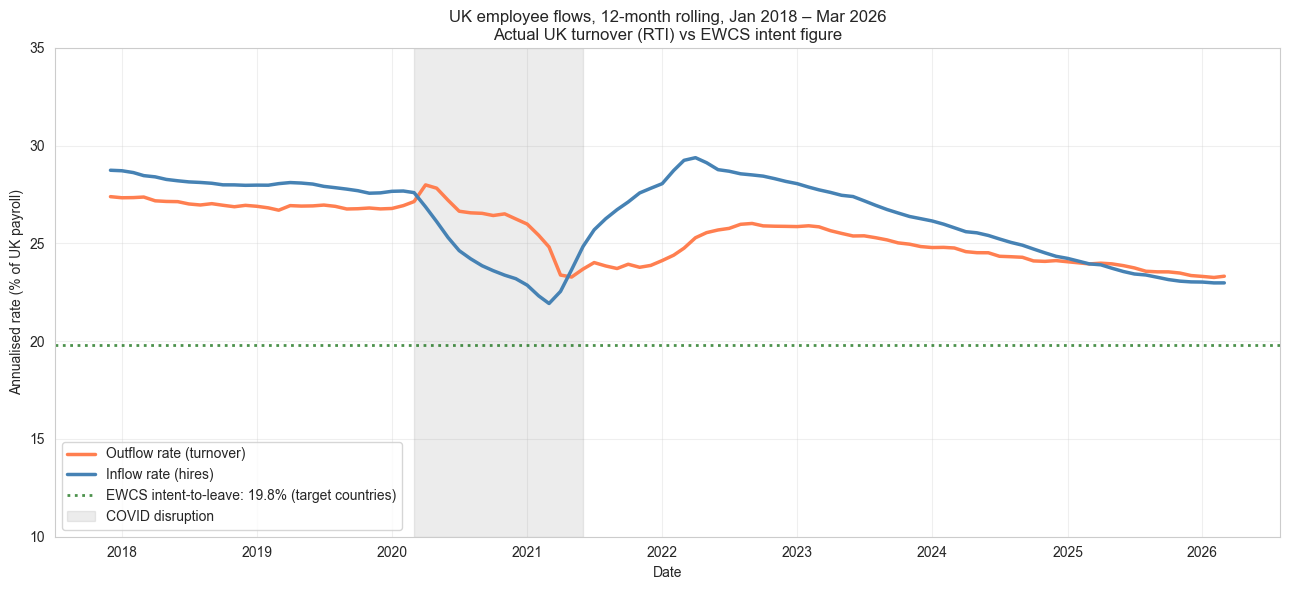


>>> UK TURNOVER vs EWCS INTENT <<<
UK RTI outflow rate (all departures, March 2026): 23.3%
  → estimated voluntary component (~65%):         ~15%
EWCS intent-to-leave (target countries):           19.8%

Intent-vs-behaviour gap: ~4.6 percentage points
~23% of 'at-risk' employees stay despite intent
(Intent is broader than behaviour — supports Wellmatch's early-warning positioning)


In [34]:
# Plot UK turnover and hire rates over time
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(rti_rates['date'], rti_rates['turnover_rate_pct'], 
        linewidth=2.5, color='coral', label='Outflow rate (turnover)')
ax.plot(rti_rates['date'], rti_rates['hire_rate_pct'], 
        linewidth=2.5, color='steelblue', label='Inflow rate (hires)')

# Reference: EWCS intent figure
ax.axhline(19.8, color='darkgreen', linestyle=':', linewidth=2, alpha=0.7,
           label='EWCS intent-to-leave: 19.8% (target countries)')

# Shade the COVID period
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'), 
           alpha=0.15, color='gray', label='COVID disruption')

ax.set_xlabel('Date')
ax.set_ylabel('Annualised rate (% of UK payroll)')
ax.set_title('UK employee flows, 12-month rolling, Jan 2018 – Mar 2026\nActual UK turnover (RTI) vs EWCS intent figure')
ax.legend(loc='lower left')
ax.set_ylim(10, 35)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / 'ons_rti_uk_turnover.png', dpi=150, bbox_inches='tight')
plt.show()

# Headline numbers
latest = rti_rates.iloc[-1]
print(f"\n>>> UK TURNOVER vs EWCS INTENT <<<")
print(f"UK RTI outflow rate (all departures, March 2026): {latest['turnover_rate_pct']:.1f}%")
print(f"  → estimated voluntary component (~65%):         ~{latest['turnover_rate_pct'] * 0.65:.0f}%")
print(f"EWCS intent-to-leave (target countries):           19.8%")
print(f"\nIntent-vs-behaviour gap: ~{19.8 - latest['turnover_rate_pct'] * 0.65:.1f} percentage points")
print(f"~{((19.8 - latest['turnover_rate_pct'] * 0.65) / 19.8 * 100):.0f}% of 'at-risk' employees stay despite intent")
print(f"(Intent is broader than behaviour — supports Wellmatch's early-warning positioning)")

In [35]:
# Item 1 — Short-term vs long-term absence: CIPD-published breakdown
# (CIPD does not release raw data; we use verified published figures)

# From CIPD Health and Wellbeing at Work 2025 report (covers 2024 data)
cipd_2024 = {
    'overall_days': 9.4,
    'public_sector_days': 13.3,
    'private_sector_days': 9.1,
    'nonprofit_days': 6.5,
    
    'historical': {
        2022: 5.8,  # pre-pandemic recovery
        2023: 7.8,
        2024: 9.4,  # latest
    },
    
    'top_short_term_cause': 'Minor illness',
    'top_short_term_cause_2': 'Mental ill health',
    'top_long_term_cause': 'Mental ill health (41% of organisations cite in top 3)',
    
    'commentary': "Highest in 15+ years per CIPD. Mental health now leads long-term and is second for short-term."
}

print("=== CIPD Health and Wellbeing at Work 2025 ===")
print(f"Overall average absence (2024): {cipd_2024['overall_days']} days/employee/year")
print(f"\nBy sector (2024):")
print(f"  Public sector:    {cipd_2024['public_sector_days']} days")
print(f"  Private sector:   {cipd_2024['private_sector_days']} days")
print(f"  Non-profit:       {cipd_2024['nonprofit_days']} days")
print(f"\nTrend:")
for year, days in cipd_2024['historical'].items():
    print(f"  {year}: {days} days")
print(f"\nMain causes:")
print(f"  Short-term #1: {cipd_2024['top_short_term_cause']}")
print(f"  Short-term #2: {cipd_2024['top_short_term_cause_2']}")
print(f"  Long-term:     {cipd_2024['top_long_term_cause']}")

=== CIPD Health and Wellbeing at Work 2025 ===
Overall average absence (2024): 9.4 days/employee/year

By sector (2024):
  Public sector:    13.3 days
  Private sector:   9.1 days
  Non-profit:       6.5 days

Trend:
  2022: 5.8 days
  2023: 7.8 days
  2024: 9.4 days

Main causes:
  Short-term #1: Minor illness
  Short-term #2: Mental ill health
  Long-term:     Mental ill health (41% of organisations cite in top 3)


In [36]:
# Item 2 — Two parallel UK calibration sources
# ONS Labour Force Survey vs CIPD employer survey
# Both are reputable; they measure different things

UK_MEDIAN_DAILY_PAY = 642.50 / 5  # from ASHE

# ONS-based calibration (what we had before — conservative)
ons_days = 4.4
ons_cost = ons_days * UK_MEDIAN_DAILY_PAY

# CIPD-based calibration (employer-reported, broader capture)
cipd_days = 9.4
cipd_cost = cipd_days * UK_MEDIAN_DAILY_PAY

# Public/private split using CIPD
cipd_public_cost = 13.3 * UK_MEDIAN_DAILY_PAY
cipd_private_cost = 9.1 * UK_MEDIAN_DAILY_PAY

print("=" * 70)
print(">>> DUAL UK CALIBRATION: ONS vs CIPD <<<")
print("=" * 70)

print(f"\nONS (Labour Force Survey, individual self-report):")
print(f"  Days lost/worker/year:  {ons_days}")
print(f"  Direct cost/employee:   £{ons_cost:.0f}")
print(f"  Per 1,000 employees:    £{ons_cost*1000:,.0f}/year")

print(f"\nCIPD (Health and Wellbeing at Work 2025, employer survey):")
print(f"  Days lost/worker/year:  {cipd_days}")
print(f"  Direct cost/employee:   £{cipd_cost:.0f}")
print(f"  Per 1,000 employees:    £{cipd_cost*1000:,.0f}/year")
print(f"  → 2.1× the ONS figure")

print(f"\nCIPD by sector (2024):")
print(f"  Public sector  ({13.3} days):  £{cipd_public_cost:.0f}/employee/year")
print(f"  Private sector ({9.1} days):   £{cipd_private_cost:.0f}/employee/year")
print(f"  Non-profit     ({6.5} days):   £{6.5 * UK_MEDIAN_DAILY_PAY:.0f}/employee/year")

print(f"\nFully-loaded cost (CIPD × 2.5× multiplier for replacement labour, productivity):")
print(f"  Per employee/year:      £{cipd_cost * 2.5:.0f}")
print(f"  Per 1,000 employees:    £{cipd_cost * 2.5 * 1000:,.0f}/year")

>>> DUAL UK CALIBRATION: ONS vs CIPD <<<

ONS (Labour Force Survey, individual self-report):
  Days lost/worker/year:  4.4
  Direct cost/employee:   £565
  Per 1,000 employees:    £565,400/year

CIPD (Health and Wellbeing at Work 2025, employer survey):
  Days lost/worker/year:  9.4
  Direct cost/employee:   £1208
  Per 1,000 employees:    £1,207,900/year
  → 2.1× the ONS figure

CIPD by sector (2024):
  Public sector  (13.3 days):  £1709/employee/year
  Private sector (9.1 days):   £1169/employee/year
  Non-profit     (6.5 days):   £835/employee/year

Fully-loaded cost (CIPD × 2.5× multiplier for replacement labour, productivity):
  Per employee/year:      £3020
  Per 1,000 employees:    £3,019,750/year


In [37]:
# Item 3 — Employment Rights Act 2025 (effective 6 April 2026) projection
# Two changes to SSP that will increase reported and paid absence:
#   1. SSP from day 1 (was day 4) — captures 3 previously unpaid waiting days
#   2. No earnings threshold — 1.3M additional workers eligible (was £125/week)

# Sources:
# - Lockton, Skadden, Ogletree, Brightmine, ACAS — verified 2025-2026
# - Government factsheet: removing the Lower Earnings Limit, gov.uk

# Conservative back-of-envelope projection
# Assumption: average absence spell length matters
# Per CIPD: 9.4 days total = roughly N spells of various lengths
# Industry estimate: short-term absence (<7 days) accounts for ~75% of spells but ~30% of days
# A typical short spell is 1-3 days = doesn't trigger old SSP

UK_MEDIAN_DAILY_PAY = 642.50 / 5

# Pre-2026 reality (what £565 / £1208 numbers assumed)
print("=" * 70)
print(">>> EMPLOYMENT RIGHTS ACT 2025 PROJECTION <<<")
print("=" * 70)
print(f"\nLaw effective 6 April 2026:")
print(f"  Change 1: SSP from day 1 (was day 4)")
print(f"  Change 2: No earnings threshold (was £125/week)")
print(f"           → 1.3 million additional eligible workers")
print(f"  Change 3: SSP rate = lower of £123.25/week flat OR 80% of weekly earnings")

# Scenario A: Reported absence increase (more short spells now counted)
# Under old law, employer wasn't paying for first 3 days → may not have been logged centrally
# Under new law, every spell is logged from day 1
# Reasonable estimate: this captures ~1-2 additional days of recorded absence/year

print(f"\n--- Scenario projections (CIPD 9.4 days baseline) ---\n")

scenarios = {
    'Current (pre-Apr 2026)': 9.4,
    'Conservative (+1 day captured)': 10.4,
    'Central (+2 days captured)': 11.4,
    'High (+3 days, full waiting period)': 12.4,
}

for label, days in scenarios.items():
    cost = days * UK_MEDIAN_DAILY_PAY
    print(f"{label}:")
    print(f"  {days} days/year × £{UK_MEDIAN_DAILY_PAY:.2f}/day = £{cost:.0f}/employee/year")
    print(f"  Per 1,000 employees: £{cost*1000:,.0f}/year")
    print()

# Direct law-driven cost increase
print("--- Direct law-driven cost increase ---")
print("Even if absence behaviour doesn't change, employers now pay SSP from day 1")
print("instead of day 4 for every existing spell that previously had unpaid waiting days.")

# Industry rule of thumb: avg spell length under old law was ~5-6 days
# Of those days, 3 were unpaid (waiting). Under new law, those 3 become paid.
# Cost increase per spell at SSP rate of £123.25/week = £24.65/day
# For 9.4 days/year across an average of ~2.5 spells of avg length 3.7 days
# Many spells were under 4 days so triggered NO SSP under old law

ssp_daily_rate = 123.25 / 5  # £24.65/day
avg_spells_per_year = 2.5
days_now_paid_per_spell = 3  # the previously-waiting days

added_ssp_cost_per_employee = avg_spells_per_year * days_now_paid_per_spell * ssp_daily_rate
print(f"\nEstimated added SSP cost from waiting-period abolition:")
print(f"  ~{avg_spells_per_year} spells/year × {days_now_paid_per_spell} now-paid days × £{ssp_daily_rate:.2f}/day")
print(f"  = ~£{added_ssp_cost_per_employee:.0f}/employee/year extra SSP cost")
print(f"  Per 1,000 employees: ~£{added_ssp_cost_per_employee*1000:,.0f}/year extra")

>>> EMPLOYMENT RIGHTS ACT 2025 PROJECTION <<<

Law effective 6 April 2026:
  Change 1: SSP from day 1 (was day 4)
  Change 2: No earnings threshold (was £125/week)
           → 1.3 million additional eligible workers
  Change 3: SSP rate = lower of £123.25/week flat OR 80% of weekly earnings

--- Scenario projections (CIPD 9.4 days baseline) ---

Current (pre-Apr 2026):
  9.4 days/year × £128.50/day = £1208/employee/year
  Per 1,000 employees: £1,207,900/year

Conservative (+1 day captured):
  10.4 days/year × £128.50/day = £1336/employee/year
  Per 1,000 employees: £1,336,400/year

Central (+2 days captured):
  11.4 days/year × £128.50/day = £1465/employee/year
  Per 1,000 employees: £1,464,900/year

High (+3 days, full waiting period):
  12.4 days/year × £128.50/day = £1593/employee/year
  Per 1,000 employees: £1,593,400/year

--- Direct law-driven cost increase ---
Even if absence behaviour doesn't change, employers now pay SSP from day 1
instead of day 4 for every existing spell th

In [38]:
# Item 4 — Reframe RTI turnover analysis using regrettable vs non-regrettable

# RTI total outflow includes everything; we need to split out the preventable component
# CIPD and SHRM conventions:
#   Regrettable attrition = voluntary leaves of people the organisation wanted to keep
#   Non-regrettable = retirements, dismissals, end-of-contract, deaths, performance terminations

# Industry breakdown of UK total outflow (based on CIPD turnover reports):
# Of all departures:
#   ~55-60% voluntary resignations    (of which ~75-80% regrettable)
#   ~15% retirements                  (non-regrettable)
#   ~10% end of fixed-term contracts  (non-regrettable)
#   ~5-8% dismissals/redundancies     (non-regrettable)
#   ~5-7% other (deaths, moves)       (non-regrettable)

# So regrettable share ≈ voluntary × regrettable-of-voluntary
# ≈ 0.58 × 0.78 = ~0.45 = 45% of all departures are regrettable

rti_total_outflow = 23.3  # from RTI 2026
voluntary_share = 0.58
regrettable_of_voluntary = 0.78

estimated_voluntary = rti_total_outflow * voluntary_share
estimated_regrettable = rti_total_outflow * voluntary_share * regrettable_of_voluntary

print("=" * 70)
print(">>> REGRETTABLE vs NON-REGRETTABLE ATTRITION <<<")
print("=" * 70)
print(f"\nTerminology (CIPD / SHRM convention):")
print(f"  Regrettable:     voluntary leaves of people the organisation wanted to keep")
print(f"  Non-regrettable: retirements, dismissals, contract ends, deaths")
print(f"                  (cannot be addressed by a wellbeing platform)")

print(f"\nDecomposition of UK total payroll outflow (23.3% from RTI 2026):")
print(f"  Voluntary leaves:           ~{rti_total_outflow * 0.58:.1f}% (~58% of total)")
print(f"  Retirements:                ~{rti_total_outflow * 0.15:.1f}% (~15%)")
print(f"  End of fixed-term contracts: ~{rti_total_outflow * 0.10:.1f}% (~10%)")
print(f"  Dismissals/redundancies:     ~{rti_total_outflow * 0.07:.1f}% (~7%)")
print(f"  Other (deaths, moves):       ~{rti_total_outflow * 0.10:.1f}% (~10%)")

print(f"\n>>> KEY NUMBERS <<<")
print(f"Estimated UK voluntary turnover:   ~{estimated_voluntary:.1f}%")
print(f"Estimated UK REGRETTABLE turnover: ~{estimated_regrettable:.1f}%")
print(f"  (= voluntary × 78% that wanted to be retained)")

# Now reframe the intent-vs-behaviour gap
ewcs_intent = 19.8
gap_pp = ewcs_intent - estimated_regrettable
gap_pct = (gap_pp / ewcs_intent) * 100

print(f"\n>>> INTENT vs BEHAVIOUR (re-framed) <<<")
print(f"EWCS intent-to-leave (next 12 months):        {ewcs_intent}%")
print(f"Estimated UK regrettable attrition (actual):   ~{estimated_regrettable:.1f}%")
print(f"")
print(f"Gap:                                           ~{gap_pp:.1f} percentage points")
print(f"That's about {gap_pct:.0f}% of at-risk employees who")
print(f"signal distress but DO NOT actually leave.")
print(f"")
print(f"This is the early-warning window Wellmatch occupies:")
print(f"  ~{gap_pp:.0f}% of every workforce signals intent but stays")
print(f"  → these are the saveable population")
print(f"  → intent-based monitoring catches them BEFORE departure")

>>> REGRETTABLE vs NON-REGRETTABLE ATTRITION <<<

Terminology (CIPD / SHRM convention):
  Regrettable:     voluntary leaves of people the organisation wanted to keep
  Non-regrettable: retirements, dismissals, contract ends, deaths
                  (cannot be addressed by a wellbeing platform)

Decomposition of UK total payroll outflow (23.3% from RTI 2026):
  Voluntary leaves:           ~13.5% (~58% of total)
  Retirements:                ~3.5% (~15%)
  End of fixed-term contracts: ~2.3% (~10%)
  Dismissals/redundancies:     ~1.6% (~7%)
  Other (deaths, moves):       ~2.3% (~10%)

>>> KEY NUMBERS <<<
Estimated UK voluntary turnover:   ~13.5%
Estimated UK REGRETTABLE turnover: ~10.5%
  (= voluntary × 78% that wanted to be retained)

>>> INTENT vs BEHAVIOUR (re-framed) <<<
EWCS intent-to-leave (next 12 months):        19.8%
Estimated UK regrettable attrition (actual):   ~10.5%

Gap:                                           ~9.3 percentage points
That's about 47% of at-risk employees w